In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
url = "https://raw.githubusercontent.com/rashida048/Datasets/master/StudentsPerformance.csv"
df = pd.read_csv(url)
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
print("Dataset Shape:")
print(df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(1000, 8)

Column Names:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

Data Types:
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

Missing Values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [6]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [7]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [8]:
# Remove duplicate rows if any
df = df.drop_duplicates()
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (1000, 8)


In [9]:
# Value counts for categorical features
print("Gender:")
print(df["gender"].value_counts())
print("\nRace/Ethnicity:")
print(df["race/ethnicity"].value_counts())
print("\nParental Level of Education:")
print(df["parental level of education"].value_counts())
print("\nLunch:")
print(df["lunch"].value_counts())
print("\nTest Preparation Course:")
print(df["test preparation course"].value_counts())

Gender:
gender
female    518
male      482
Name: count, dtype: int64

Race/Ethnicity:
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

Parental Level of Education:
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

Lunch:
lunch
standard        645
free/reduced    355
Name: count, dtype: int64

Test Preparation Course:
test preparation course
none         642
completed    358
Name: count, dtype: int64


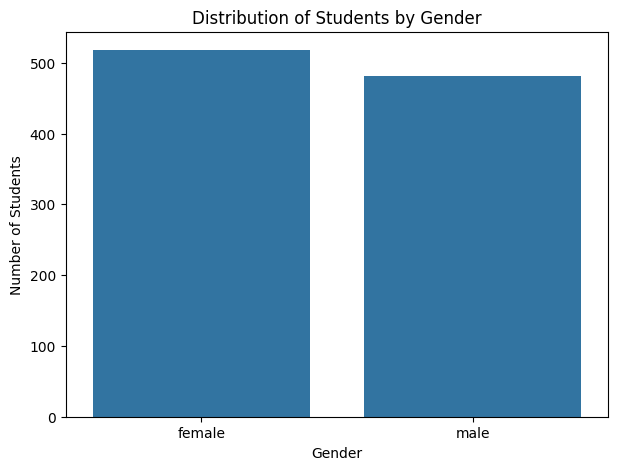

In [10]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="gender")
plt.title("Distribution of Students by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Students")
plt.show()

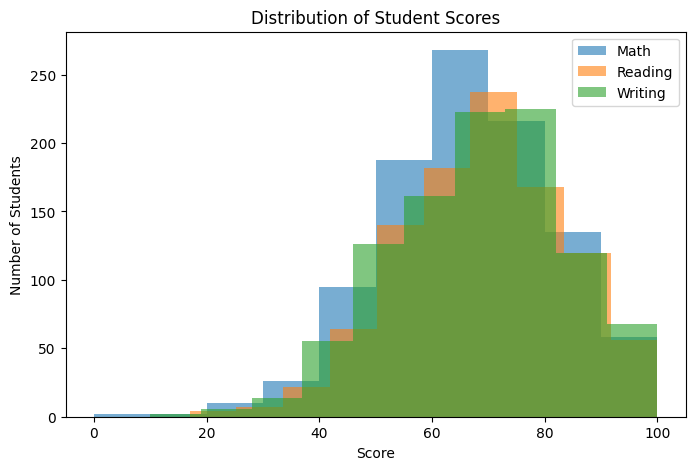

In [11]:
plt.figure(figsize=(8,5))
plt.hist(df["math score"], bins=10, alpha=0.6, label="Math")
plt.hist(df["reading score"], bins=10, alpha=0.6, label="Reading")
plt.hist(df["writing score"], bins=10, alpha=0.6, label="Writing")
plt.title("Distribution of Student Scores")
plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.legend()
plt.show()

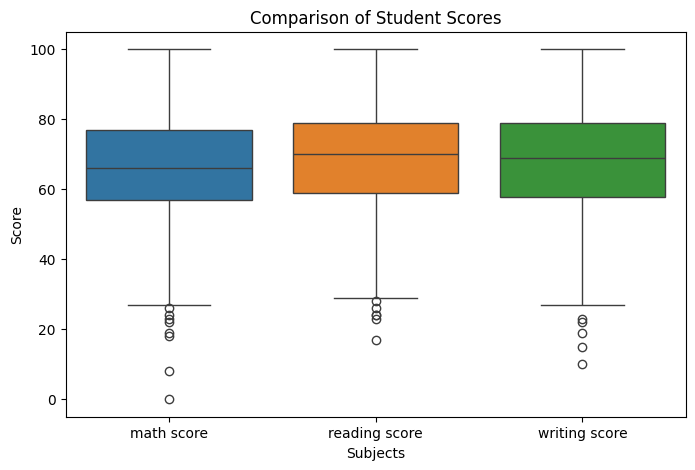

In [12]:
# Boxplot of student scores
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[['math score', 'reading score', 'writing score']])
plt.title("Comparison of Student Scores")
plt.xlabel("Subjects")
plt.ylabel("Score")
plt.show()

In [13]:
# Correlation between student scores
correlation = df[['math score', 'reading score', 'writing score']].corr()
print("Correlation Matrix:")
print(correlation)

Correlation Matrix:
               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


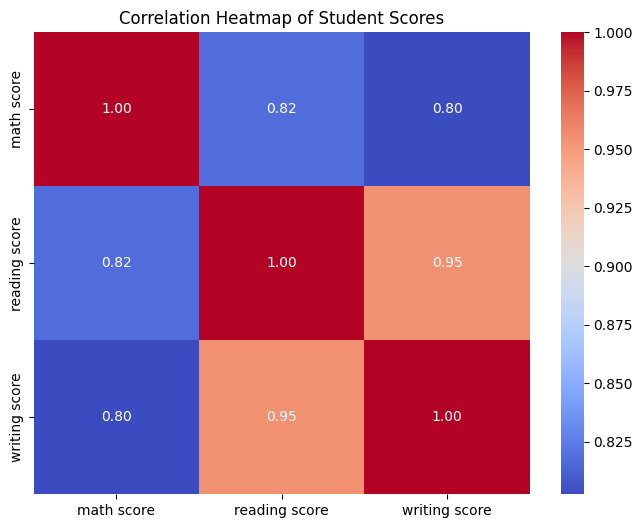

In [14]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Student Scores")
plt.show()

In [15]:
# Average scores by gender
gender_scores = df.groupby('gender')[['math score', 'reading score', 'writing score']].mean()
print("Average Scores by Gender:")
print(gender_scores)

Average Scores by Gender:
        math score  reading score  writing score
gender                                          
female   63.633205      72.608108      72.467181
male     68.728216      65.473029      63.311203


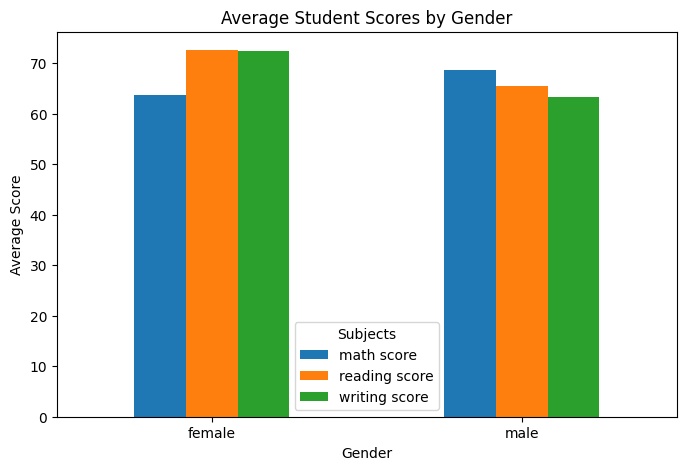

In [16]:
# Visualize average scores by gender
gender_scores.plot(kind='bar', figsize=(8, 5))
plt.title("Average Student Scores by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(title="Subjects")
plt.show()

In [17]:
# Compare scores based on test preparation course
prep_scores = df.groupby('test preparation course')[
    ['math score', 'reading score', 'writing score']
].mean()
print("Average Scores by Test Preparation Course:")
print(prep_scores)

Average Scores by Test Preparation Course:
                         math score  reading score  writing score
test preparation course                                          
completed                 69.695531      73.893855      74.418994
none                      64.077882      66.534268      64.504673


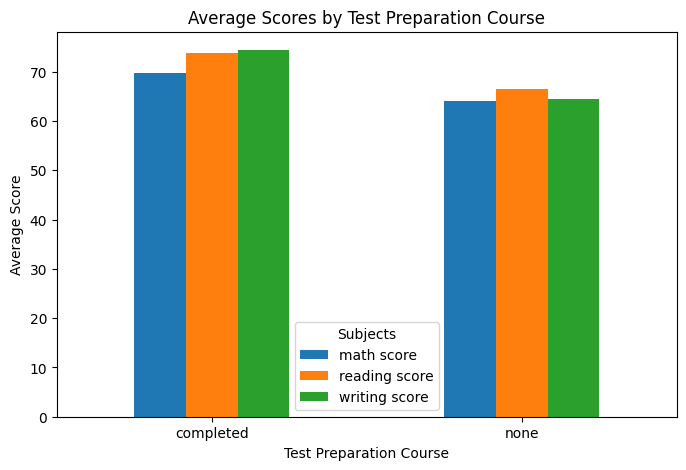

In [18]:
# Visualize scores by test preparation course
prep_scores.plot(kind='bar', figsize=(8, 5))
plt.title("Average Scores by Test Preparation Course")
plt.xlabel("Test Preparation Course")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(title="Subjects")
plt.show()

In [19]:
# Final EDA Insights
print("FINAL EDA INSIGHTS")
print("=" * 50)
print("1. The dataset contains 1000 student records with no missing values.")
print("2. No duplicate rows were found in the dataset.")
print("3. Reading and writing scores have the strongest correlation (0.95).")
print("4. Male students have a higher average math score.")
print("5. Female students have higher average reading and writing scores.")
print("6. Students who completed test preparation scored higher in all three subjects.")
print("7. Several low-score outliers were observed, particularly in math scores.")
print("8. Most student scores are concentrated between approximately 50 and 85.")

FINAL EDA INSIGHTS
1. The dataset contains 1000 student records with no missing values.
2. No duplicate rows were found in the dataset.
3. Reading and writing scores have the strongest correlation (0.95).
4. Male students have a higher average math score.
5. Female students have higher average reading and writing scores.
6. Students who completed test preparation scored higher in all three subjects.
7. Several low-score outliers were observed, particularly in math scores.
8. Most student scores are concentrated between approximately 50 and 85.


# Conclusion

The Exploratory Data Analysis provided useful insights into student performance.

- The dataset contains 1000 student records with no missing values.
- No duplicate records were found.
- Reading and writing scores have a very strong positive correlation.
- Male students have a higher average math score, while female students have higher average reading and writing scores.
- Students who completed the test preparation course performed better across all three subjects.
- The score distributions show that most students performed within the middle-to-high score range.
- Some low-score outliers were identified, particularly in math.

Overall, the analysis shows that test preparation and performance in different subjects are important factors associated with student scores.